# **Tema d'esame di Statistica e analisi dei dati**

## **1.1 Prova scritta del 4 febbraio 2025 – Prof. Malchiodi**
Scrivete qui sotto i dati richiesti e riportateli anche su tutti i fogli protocollo che vi sono stati consegnati. Non potete tenere altri fogli bianchi rispetto a quelli che vi sono stati consegnati, né potete utilizzare calcolatrici portatili (avete a disposizione direttamente il computer!). Potete tenere sul banco, oltre alla penna, un libro e un quaderno di appunti per consultazione. Tutte le altre cose che avete con voi, **compresi telefoni e smartwatch**, devono essere riposte nello zaino e lasciate ai banchi, dove vi verrà indicato. Potete scegliere a quali domande rispondere scrivendo su carta e a quali scrivendo ed eseguendo direttamente codice in questo notebook.

A fine prova dovrete consegnare **tutti** i fogli che vi sono stati dati, e inviare la versione digitale di questo notebook, contenente il vostro svolgimento, utilizzando il sito [https://upload.di.unimi.it](https://upload.di.unimi.it).

**Cognome e nome:**  
**Matricola:**

## **Esercizio 1**
Data una variabile aleatoria $X$ distribuita secondo un modello binomiale di parametri $n$ e $p$ definiamo $Z = 2X$.

**1.** Quali sono le specificazioni di $Z$?

In [1]:
# Z non ha una distribuzione nota 
# Z ha come dominio i numeri pari da 0 a 2n

**2.** Calcolate $P(Z = 0)$ e $P(Z = 2n)$.

In [2]:
# P(Z = 0) = P(2X /2= 0 /2) = P(X=0) 
# (n,x) * p^x * (1-p)^(n-x) = n!/[(n-0)!*0!] * 1 * (1-p)^n  = n!*(1-p)^n / n! =
# = (1-p)^n

# P(Z = 2n) = P(2X = 2n) = P(X = n)
# (n,n) * p^n * (1-p)^(n-n) = n!/(n-n)!*n! * p^n * (1-p)^0 = 1 * p^n * 1 =
# = p^n

**3.** Studiate la relazione che esiste tra $X$ e $Z$, e scrivete la forma analitica della funzione di massa di probabilità di $Z$.

In [ ]:
# Z = 2X, Z € [0,2,..,2n-2,2n]
# P(Z = k) = P(2X = k) = P(X = k/2)
# fmp di Z:
# (n k/2) * p^(k/2) * (1-p)^(n-k/2) con k divisibile per 2

**4.** Solo in questo punto dell’esercizio, assumete che $n = 3$ e $p = \frac{1}{2}$. Visualizzate graficamente la distribuzione di $Z$, giustificando il tipo di grafico scelto.

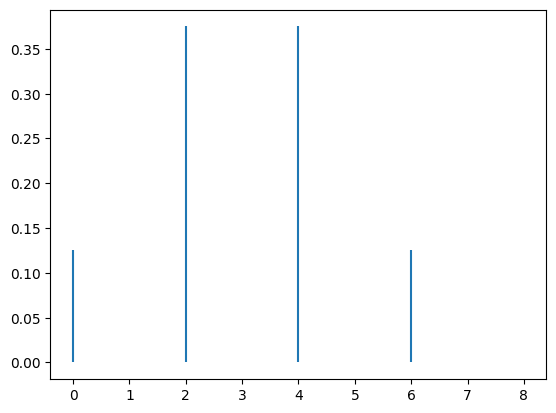

In [70]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as st
import pandas as pd
import numpy as np

n = 3
p = 1/2

X = st.binom(n,p)

x_range = np.arange(0, 10, 2)
y_range = [X.pmf(x/2) for x in x_range]

plt.vlines(x_range, 0, y_range)
plt.show()

**5.** Calcolate il valore atteso e la varianza di $Z$, esprimendoli in funzione di $p$ ed $n$ e giustificando i passaggi svolti.

In [5]:
# E(Z) = 2*E(X) = 2*np
# Var(Z) = 4*Var(X) = 4*np(1-p)

## **Esercizio 2**
Consideriamo una popolazione distribuita come una variabile aleatoria $Z$, la cui distribuzione è la stessa dell’omonima variabile definita nell’esercizio precedente, per un valore ignoto del parametro $p$ avento fissato $n = 365$. Per un $m \in N$ fissato, siano $Z_1, \dots, Z_m$ delle variabili aleatorie che descrivono un campione estratto da questa popolazione. In tutto l’esercizio, $\overline{Z}$ indicherà la media campionaria calcolata su $Z_1, \dots, Z_m$.

**1.** Di norma si usa il simbolo $n$ per indicare la dimensione di un campione. In questo esercizio, invece, è stato introdotto il simbolo $m$: era necessario? Perché?

In [6]:
# perché n è già un parametro della binomiale duh

**2.** $\overline{Z}$ è uno stimatore non deviato per la varianza di $Z$? Motivate la vostra risposta.

In [7]:
# E(Z') = Var(Z) ?
# E(Z') = E(Z) = 2np != 4np(1-p) = Var(Z)
# Z' è uno stimatore deviato per la varianza di Z

**3.** Giustificando i vostri passaggi, determinate uno stimatore $T$ non distorto per il parametro $p$.

In [8]:
# T = Z'/2n è uno stimatore non distorto per p
# motivazione: E(T) = E(Z' / 2n) = E(Z')/2n = E(Z)/n = 2np/2n = p

# magari faccio bella figura se cito il fatto di aver usato il metodo plug in su 2np = p

**4.** Giustificando i vostri passaggi, calcolate lo scarto quadratico medio dello stimatore $T$ che avete proposto al punto precedente, esprimendolo solamente in funzione di $p$ e della dimensione del campione. Verificate poi se $T$ gode della proprietà di consistenza in media quadratica.

In [ ]:
# MSE(T,p) = Var(T) + bias^2
# Var(T) = Var(Z' / 2n) = Var(Z) / m4n^2 = 4np(1-p)/4mn^2 = p(1-p)/nm
# bias = 0 dato che è non distorto
# consistenza: lim m->infinito p(1-p)/mn + 0 = p(1-p)/365*infinito = 0 quindi T è consistente

**5.** Calcolate la deviazione standard dello stimatore $T$ proposto, giustificando i passaggi effettuati.

In [10]:
# std(T) = sqrt(Var(T)) = sqrt(p(1-p)/365m)

**6.** Applicando il teorema centrale del limite e giustificando i passaggi effettuati, calcolate qual è la dimensione minima del campione che permette di asserire che l’errore (in valore assoluto) che si compie usando lo stimatore proposto per stimare $p$ se è minore o uguale a $10^{-3}$ con probabilità maggiore o uguale a $0.9$. Esprimere poi questa probabilità in funzione di $p$.

In [11]:
# P(|T-p|<=0.001) >= 0.9
# la solita storia dai non serve fare i passaggi

# 2*phi(0.001*sqrt(365m/p(1-p))) - 1 >= 0.9
# phi(0.001 * sqrt(365m / p(1-p))) >= 0.95 -> phi(k) = 0.95
# 0.001 * sqrt(m) * sqrt(365/p(1-p)) >= k
# sqrt(m) >= 1000k * sqrt(p(1-p)/365)
# m >= (1000k)^2 * p(1-p)/365  [chatgpt dice che k = 1.645 circa]
# m >= 1645^2 * p(1-p)/365

## Esercizio 3

Collegatevi al sito upload.di.unimi.it, selezionate l’esame di Statistica e analisi dei dati per l’appello odierno e scaricate il file ztl.csv. Questo file contiene le seguenti informazioni, in merito agli autoveicoli che sono acceduti alla zona a traffico limitato (ZTL) di un ipotetico comune nel periodo di un anno:

- `id-autoveicolo`: numero intero che identifica univocamente l’autoveicolo.
- `categoria`: categoria dell’utente che effettua l’accesso (“residente”, “commerciante”, “lavoratore”, “turista” o “altro”, espressi tramite stringhe).
- `abbonamento`: valore booleano che indica se il possessore dell’autoveicolo paga un abbonamento per accedere alla ZTL (1: sì, 0: no).
- `passaggi`: numero di passaggi effettuati nell’anno (numero intero); se non si possiede un abbonamento, questo numero è sempre pari perché si acquista due passaggi, uno in ingresso e uno in uscita, e non è possibile lasciare l’auto nella ZTL durante la notte.
- `altamente-inquinante`: valore booleano che indica se l’autoveicolo è più inquinante della media (1: sì, 0: no).

In questo file il carattere `;` separa le colonne.

**1.** Create un DataFrame che contenga il dataset memorizzato nel file ztl.csv, e memorizzatelo in una variabile `ztl`. Determinate quanti valori mancanti vi siano nel dataset per ogni possibile valore dell’attributo categoria.

In [12]:
ztl = pd.read_csv('ztl.csv', sep=";", na_values="")

ztl.head()

,id-autoveicolo,categoria,abbonamento,passaggi,altamente-inquinante
0,1.0,commerciante,0.0,196.0,0.0
1,2.0,altro,0.0,174.0,0.0
2,3.0,turista,0.0,192.0,1.0
3,4.0,lavoratore,0.0,192.0,1.0
4,5.0,residente,1.0,230.0,1.0


In [13]:
for c in ztl.categoria.unique():
    s = 0
    for t in ztl:
        s += sum(ztl[t][ztl.categoria==c].isna())
    print(f"Dati mancanti per {c} : {s}")

Dati mancanti per commerciante : 1
Dati mancanti per altro : 3
Dati mancanti per turista : 1
Dati mancanti per lavoratore : 2
Dati mancanti per residente : 3


**2.** Indicate il tipo dell’attributo `passaggi`, e visualizzate successivamente la sua distribuzione, motivando la scelta dello strumento grafico utilizzato.

<Axes: ylabel='Frequency'>

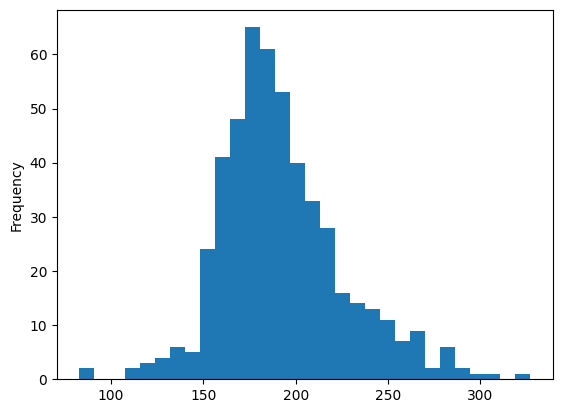

In [14]:
ztl.passaggi.plot.hist(bins=30)

# dall'istogramma e dalla descrizione dell'attributo, pare seguire una distribuzione di Poisson

**3.** Valutate se l’attributo `passaggi` contenga o meno dei valori fuori scala, rimuovendoli nel caso in cui ve ne siano.

In [15]:
max = ztl.passaggi.max()
min = ztl.passaggi.min()
med = ztl.passaggi.mean()
std =ztl.passaggi.std()
print(f"passaggi ha una media di {med}, una deviazione standard di {std} e ha come valori massimo {max} e minimo {min}")

# da questa analisi posso dire che gli estremi sono a circa 4 deviazioni standard di distanza dalla media

# prendo solo gli attributi fra il primo e il terzo quantile
Q1 = ztl.passaggi.quantile(0.25)
Q3 = ztl.passaggi.quantile(0.75)
IQR = Q3 - Q1

ztl_n = ztl[(ztl.passaggi >= Q1) & (ztl.passaggi <= Q3)]

max = ztl_n.passaggi.max()
min = ztl_n.passaggi.min()
med = ztl_n.passaggi.mean()
std =ztl_n.passaggi.std()
print(f"passaggi senza outliars ha una media di {med}, una deviazione standard di {std} e ha come valori massimo {max} e minimo {min}")

passaggi ha una media di 192.40562248995985, una deviazione standard di 33.58571317226709 e ha come valori massimo 327.0 e minimo 83.0
passaggi senza outliars ha una media di 188.15537848605578, una deviazione standard di 10.412481018286433 e ha come valori massimo 208.0 e minimo 171.0


**4.** Confrontate le tabelle delle frequenze relative cumulative per gli attributi `abbonamento` e `altamente-inquinante`.

In [16]:
# con cumulative intende aggiungere un cumsum() alla fine? perché ha poco senso
# dato che sono booleani sai già che sommeranno la freq rel. di un valore è uguale a 1-l'altro valore

pd.crosstab(ztl.abbonamento.values, "",  normalize=True)

col_0,
row_0,
0.0,0.467611
1.0,0.532389


In [17]:
pd.crosstab(ztl['altamente-inquinante'], "",  normalize=True)

col_0,
altamente-inquinante,
0.0,0.677355
1.0,0.322645


In [18]:
# l'esercizio dopo lascia intendere che il prof volesse la tabella congiunta quindi metto pure quella

pd.crosstab(ztl['abbonamento'], ztl['altamente-inquinante'], normalize=True, margins=True)

altamente-inquinante,0.0,1.0,All
abbonamento,,,
0.0,0.316430,0.152130,0.46856
1.0,0.359026,0.172414,0.53144
All,0.675456,0.324544,1.00000


**5.** Supponete che i valori degli attributi `abbonamento` e `altamente-inquinante` possano essere interpretati come due campioni (allineati caso per caso) estratti da due popolazioni, ognuna descritta da una variabile aleatoria. Sulla base del confronto effettuato al punto precedente, validate oppure rifiutate l’ipotesi che queste due variabili siano i.i.d.t

In [19]:
ztl.abbonamento.corr(ztl['altamente-inquinante'])

# lo scatter plot sarebbe poco utile in questo caso dato che si tratta di booleani, ci sono solo 4 punti ai lati

# l'indice di pearson mostra chiaramente che non c'è correlazione
# guardando la crosstab fatta prima si può vedere che non c'è correlazione
# es. 
# quando l'auto è inquintante ci sono 15% di persone che non si abbonano e il 17% che si abbonano
# mentre quando è non inquinante ci sono 31% di persone non si abbonano contro il 35% che si abbonano
# se lo vedi in questo modo, le percentuali di abbonamenti sono molto simili indipendentemente dall'inquinazione


np.float64(-0.000264151155845741)

**6.** Il grafico ottenuto utilizzando un diagramma-quantile permette di confermare la conclusione alla quale siete arrivati al punto precedente? Perché?

In [20]:
# Il qqplot non sarebbe molto informativo in questo caso
# dato che si parla di booleani, non ci sarebbero abbastanza punti

# in più non so come fare qqplot fra 2 distribuzioni concrete


**7.** Valutate se esista una relazione tra gli attributi `abbonamento` e `passaggi`, utilizzando sia uno strumento grafico che un indice numerico (e specificandone motivazione). In caso affermativo, descrivetene le caratteristiche nel dettaglio. Nel particolare caso che stiamo considerando, potreste dire che uno dei due attributi è più informativo rispetto all’altro? Perché?

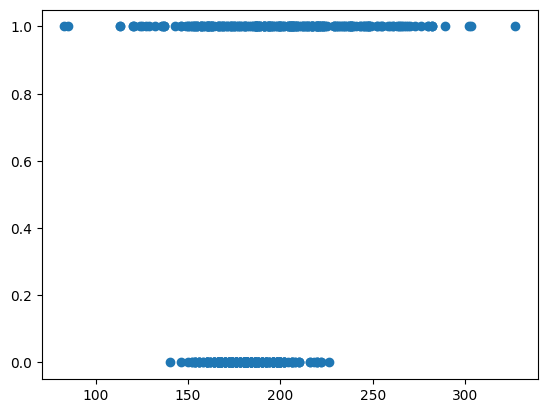

np.float64(0.2890531474388247)

In [21]:
plt.scatter(ztl.passaggi, ztl.abbonamento)
plt.show()

ztl.passaggi.corr(ztl.abbonamento)

# l'indice di pearson è vicino allo 0 e questo denota una bassa relazione

# nello scatter plot si può notare la stessa cosa
# notiamo anche che gli abbonati hanno passaggi molto più vari

**8.** Salvate in una nuova variabile `ztl_giornalieri` solo i casi del dataset che non corrispondono agli ingressi fatti con abbonamento. **Lavorare per il resto dell'esame con questo nuovo dataset**.

In [22]:
ztl_giornalieri = ztl[ztl.abbonamento == 1].dropna()

ztl_giornalieri.head()

,id-autoveicolo,categoria,abbonamento,passaggi,altamente-inquinante
4,5.0,residente,1.0,230.0,1.0
5,6.0,residente,1.0,211.0,0.0
7,8.0,turista,1.0,169.0,1.0
10,11.0,residente,1.0,188.0,0.0
12,13.0,turista,1.0,160.0,1.0


**9.** Verificare che non esista nessun caso nel dataframe con `passaggi` dispari

In [23]:
print(len(ztl_giornalieri[ztl_giornalieri.passaggi%2==1]))

# chatgpt ha fuckuppato, ci penso io un attimo
ztl_giornalieri.loc[ztl_giornalieri.passaggi % 2 == 1, 'passaggi'] += 1
   
print(len(ztl_giornalieri[ztl_giornalieri.passaggi%2==1]))

144
0


**10.** Validare l'ipotesi che `passaggi` contenga dei valori assimilabili ad un campione estratto da una popolazione la cui distribuzione sia la stessa della variabile aleatoria $Z$ dell'esercizio 1.

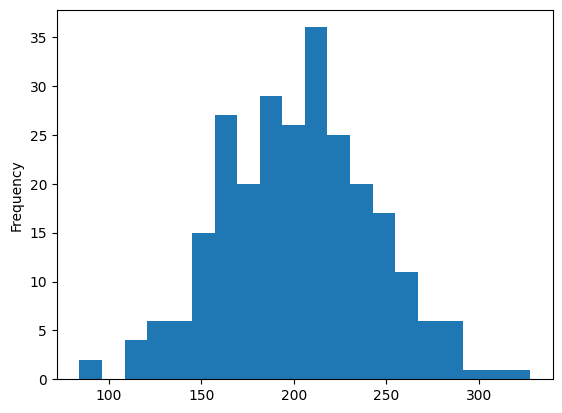

In [24]:
ztl_giornalieri.passaggi.plot.hist(bins=20)
plt.show()

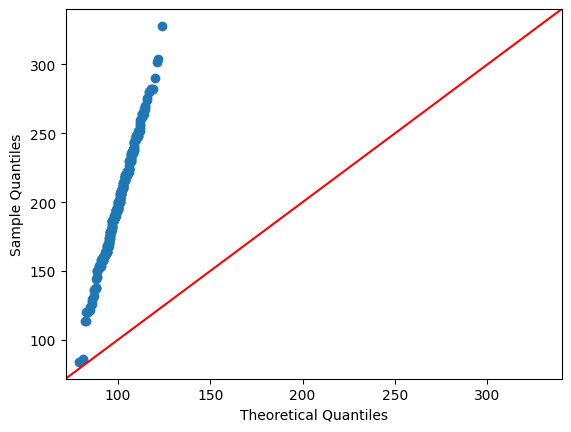

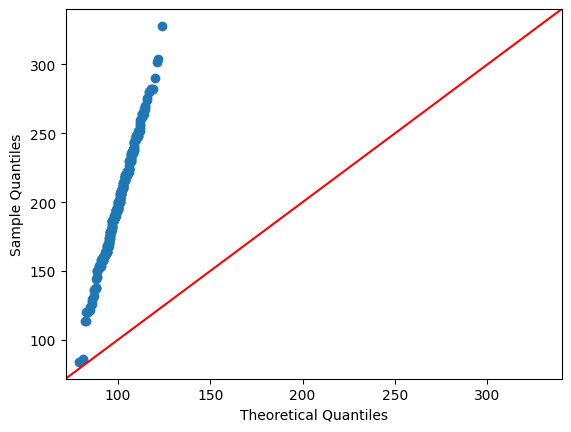

In [25]:
n = 365
p = ztl_giornalieri.passaggi.mean() / (2*n) # stima di p *occhiolino*

Z = st.binom(n, p)

sm.qqplot(ztl_giornalieri.passaggi, Z, line='45')

# non so come faare qqplot con custom cdf

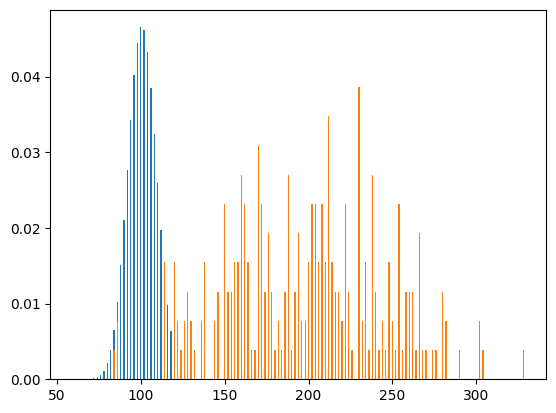

In [26]:
def Z_pmf(x): # (nz) * p^(k/2) * (1-p)^(n-k/2)
    return st.special.binom(n,x/2) * p**(x/2) * (1-p)**(n-x/2)

x_range = np.arange(60, 140, 2)
y_range = [Z.pmf(x) for x in x_range]

plt.bar(x_range, y_range)
plt.bar(ztl_giornalieri.passaggi.unique(), ztl_giornalieri.passaggi.value_counts(normalize=True))

plt.show()

# sì direi che non si assomigliano per niente, non ho idea di cosa io abbia fatto

## Esercizio 4

In questo esercizio considereremo i valori dell’attributo passaggi nel dataset memorizzato in `ztl_giornalieri` come un campione estratto da una popolazione distribuita come una variabile aleatoria $Z$ che ha l’omonima distribuzione dell’omonima variabile aleatoria introdotta nell’Esercizio 1.

**1.** Stimate la deviazione standard $\sigma_Z$ della popolazione, indicando quale statistica avete utilizzato e evidenziando se questo gode di particolari proprietà.

In [27]:
ztl_giornalieri.passaggi.std()

np.float64(41.10899727916621)

**2.** Determinate una stima numerica $\hat{p}$ per il parametro $p$ della popolazione.

In [28]:
# me lo ha già fatto fare nel 3.10?

# p' = T = Z'/2n
p = ztl_giornalieri.passaggi.mean() / (2*len(ztl_giornalieri))
p

np.float64(0.38952907678776405)

**3.** Stabilite se la quantità di dati a disposizione ci permette di dire che la stima  di $p$ fatta al punto precedente comporta un errore (in valore assoluto) rispetto al valore sconosciuto che è minore o uguale a $10^{−3}$ con probabilità maggiore o uguale a 0.9.

In [29]:
# già lo abbiamo calcolato all'inizio

# m >= 1645^2 * p(1-p)/365

print(f"{len(ztl_giornalieri)} >= {1645**2 * p*(1-p)/365}? no") 
# a quanto pare non abbiamo abbastanza dati a disposizione

259 >= 1762.9654651825858? no


**4.** Usando la stima $\hat{p}$ determinata al punto 2 al posto del valore ignoto $p$ e assumendo che n = 365, calcolate le seguenti probabilità:

   - $P(Z\ge 200)$
   - $P(Z\le 200)$
   - $P(Z\ge 240 | Z \ge 200)$

   Suggerimento: ricordate in che modo è stata definita la variabile aleatoria $Z$ nel primo esercizio.

In [ ]:
X = st.binom(365, p)

c = X.cdf(100)
# P(Z >= 200) = 1 - P(Z <= 199) = 1 - P(X <= 99)
print(f"P(Z >= 200) = {1 - X.cdf(99)}")
# P(Z <= 200) = P(X <= 100)
print(f"P(Z <= 200) = {c}")
# P(Z >= 240 dato Z >= 200) = P(Z >= 240) inters. P(Z >= 200) / P(Z>=200) 
# per logica P(Z >= 240) int. P(Z >= 200) = P(Z >= 240) -> 1 - P(X <= 120)
# (1 - P(X <= 120) ) / P(X <= 100)
print(f"P(Z >= 240 | P(Z >= 200)) = {(1-X.cdf(120))/c}")

# c'è qualcosa che non va negli output ma almeno il ragionamento è giusto

P(Z >= 200) = 4.417013718213833e-19
P(Z <= 200) = 1.1844207405761897e-18
P(Z >= 240 | P(Z >= 200)) = 8.442945700913143e+17


**5.** Gli esperti dell’ufficio viabilità ritengono che in un anno ci siano 1000 diversi utenti non abbonati che acquistano l’ingresso nella ZTL del Comune, e possiamo assumere che le abitudini di ognuno di essi siano indipendenti da quelle degli altri. Indichiamo con $A$ la variabile aleatoria che indica il numero totale dei loro passaggi. Calcolate il valore atteso e la deviazione standard di $A$, e sostituendo ad eventuali quantità ignote le opportune stime già fatte in questo stesso esercizio.

In [ ]:
# A = sum(i da 0 a 1000) 2X 
# E(A) = 2 * sum(i da 1 a 1000) E(X) = 2*np*1000 = 2000np 
# Var(A) = 4 * sum(i da 1 a 1000) Var(X) = 4 * np(1-p) * 1000 = 4000np(1-p)

# no non sostituisco stime, non ho neanche stimato n non mi ha mai chiesto di farlo, dovrebbe essere 365? boh

140.23046764359506
9.25238472205242


**6.** Indicate quale distribuzione (eventualmente anche approssimata) segue $A$, giustificando il vostro ragionamento.

In [ ]:
# A non segue una distribuzione nota, ma per il teorema centrale del limite può essere approssimata da:
# N -- (E(A), std(A)) = (2000np, sqrt(4000np(1-p)))

**7.** Il Ministero dei Trasporti eroga un finanziamento speciale ai comuni nei quali il numero totale dei passaggi nella ZTL fatti da utenti non abbonati nel periodo di un anno non eccede le centomila unità. Con che probabilità il Comune accederà a questo finanziamento il prossimo anno?

In [ ]:
# P(A <= 100000)
# P(A-2000np)/sqrt(4000np(1-p) <= 100000-2000np / sqrt(4000np(1-p)))
# phi(100000-2000np / sqrt(4000np(1-p)))

n = 128 # me lo sono inventato di sana pianta ma sembra starci bene

st.norm.cdf((100000-2000*n*p) / np.sqrt(4000*n*p*(1-p)))

np.float64(0.7893157481768298)